<h4>The Combined model - Supervised Classification Model</h4>

In [ ]:
# !pip install scikeras
# !pip install backtrader

In [ ]:
# library for machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error

# Libraries for Deep Learning Models
from keras.models import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasRegressor
from keras.optimizers import SGD

# Import for trade simulation
import backtrader as bt
import backtrader.indicators as btind
import backtrader.analyzers as btanalyzers

# Import other general use libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
from matplotlib import pyplot
import seaborn as sns
import yfinance as yf
from datetime import datetime, date
import warnings
warnings.filterwarnings('ignore')
import joblib

In [ ]:
# The data period used to train and test the combined model is 2023/12/1 to 2024/11/30.
endDate = date(2024, 11, 30)
startDate = date(2023, 12, 1)

# Just like the technical analysis model, as it can be relied more on news for an index and more on technical for a stock.
# The training of the model can be perform with each user input of ticker.
# However, to simplify and reduce the loading time, the pre-trained model will be used for the final product.
# Below is using S&P500 to train and test the combined model.
target_tickers = ['^GSPC']
dataset = yf.download(target_tickers, start = startDate, end = endDate, interval = '1d')
dataset.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
dataset = dataset.reset_index()
dataset['return'] = dataset['Open'].pct_change().shift(-1)
dataset['Date'] = pd.to_datetime(dataset['Date']).dt.date

[*********************100%***********************]  1 of 1 completed


In [ ]:
# get the indicator previously generated in the technical analysis model
TA_Data = pd.read_csv('TA_model/TA_Data.csv')
TA_Data = TA_Data[['Date', 'TA_estReturn']]
TA_Data['Date'] = pd.to_datetime(TA_Data['Date']).dt.date
dataset = pd.merge(dataset, TA_Data, how = 'left', left_on = ['Date'], right_on = ['Date'])

In [ ]:
# get the indicator previously generated in the reinforcement learning model
RL_Data = pd.read_csv('RL_model/RL_Data.csv')
RL_Data = RL_Data[['Date', 'signal_RL']]
RL_Data.columns = ['Date', 'RL_signal']
RL_Data['Date'] = pd.to_datetime(RL_Data['Date']).dt.date
dataset = pd.merge(dataset, RL_Data, how = 'left', left_on = ['Date'], right_on = ['Date'])

In [ ]:
# get the indicator previously generated in the sentiment analysis model
SA_Data = pd.read_csv('SA_model/sentiment_Data.csv')
SA_Data = SA_Data[['Date', 'sentiment_LSTM']]
SA_Data.columns = ['Date', 'SA_sentiment']
SA_Data['Date'] = pd.to_datetime(SA_Data['Date']).dt.date
dataset = pd.merge(dataset, SA_Data, how = 'left', left_on = ['Date'], right_on = ['Date'])
dataset = dataset.dropna()

In [ ]:
# For the classification, when the return of the coming day is positve, then this represent buy (i.e. 1), otherwise it represent sell (i.e. 0)
dataset['buy'] = np.where(dataset['return'] > 0, 1, 0)
dataset = dataset.sort_values(by = 'Date', ascending = True)
dataset = dataset.set_index('Date')
dataset

,Close,High,Low,Open,Volume,return,TA_estReturn,RL_signal,SA_sentiment,buy
Date,,,,,,,,,,
2023-12-04,4569.779785,4572.370117,4546.720215,4564.370117,4369910000,-0.001560,-0.000482,1.0,0.317073,0
2023-12-05,4567.180176,4578.560059,4551.680176,4557.250000,3909950000,0.006359,-0.000829,1.0,0.074074,1
2023-12-06,4549.339844,4590.740234,4546.500000,4586.229980,4245680000,-0.003792,-0.009409,1.0,0.361702,0
2023-12-07,4585.589844,4590.919922,4565.220215,4568.839844,3818880000,0.001611,0.016515,1.0,0.409091,1
2023-12-08,4604.370117,4609.229980,4574.060059,4576.200195,3707010000,0.003756,0.010942,1.0,0.454545,1
...,...,...,...,...,...,...,...,...,...,...
2024-11-21,5948.709961,5963.319824,5887.259766,5940.580078,4230120000,0.000636,0.005655,0.0,0.111111,1
2024-11-22,5969.339844,5972.899902,5944.359863,5944.359863,4141420000,0.008061,0.004527,0.0,0.266667,1
2024-11-25,5987.370117,6020.750000,5963.910156,5992.279785,5633150000,0.001293,-0.003242,0.0,0.487179,1


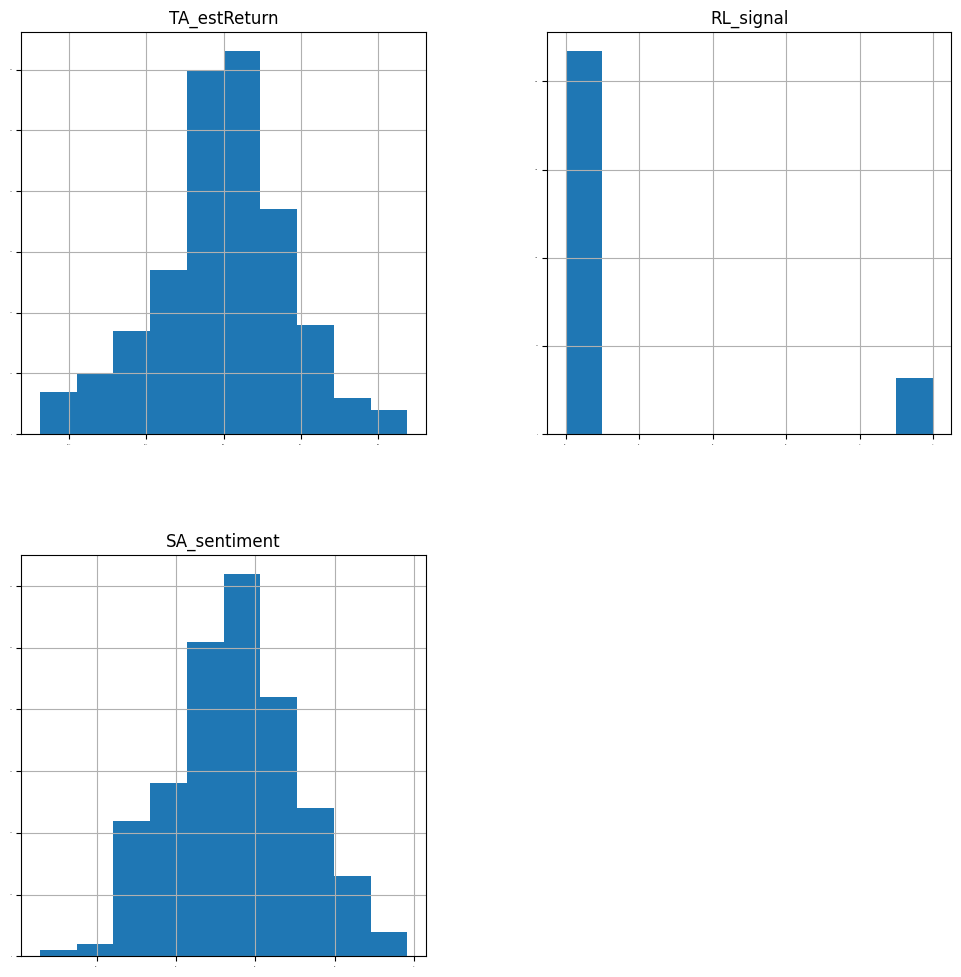

In [ ]:
# histograms for each feature
dataset[['TA_estReturn', 'RL_signal', 'SA_sentiment']].hist(sharex = False, sharey = False, xlabelsize = 1, ylabelsize = 1, figsize = (12, 12))
plt.show()

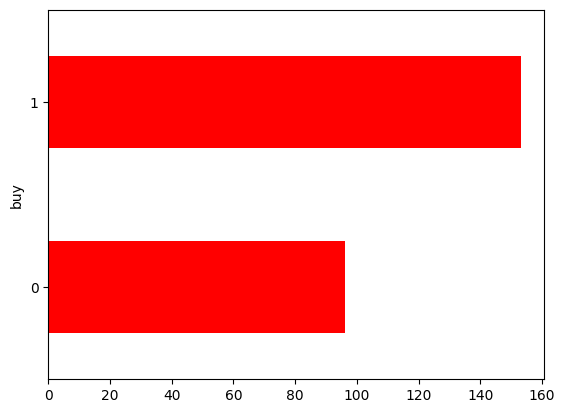

In [ ]:
# demonstrate how much buy and sell
fig = plt.figure()
plot = dataset.groupby(['buy']).size().plot(kind = 'barh', color = 'red')
plt.show()

In [ ]:
# Train Test Split. Since this is time series, just split without shuffle.
Y = dataset['buy']
X = dataset[['TA_estReturn', 'RL_signal', 'SA_sentiment']]
validation_size = 0.3
train_size = int(len(X) * (1 - validation_size))
X_train, X_test = X[0:train_size], X[train_size:len(X)]
Y_train, Y_test = Y[0:train_size], Y[train_size:len(X)]

In [ ]:
# Basics model settings
num_folds = 10
seed = 7
scoring = 'accuracy'
#scoring = 'precision'
#scoring = 'recall'
#scoring = 'neg_log_loss'
#scoring = 'roc_auc'

In [ ]:
# Compare Models
models = []
models.append(('LR', LogisticRegression(n_jobs = -1)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
#Neural Network
models.append(('NN', MLPClassifier()))
#Ensable Models
# Boosting methods
models.append(('AB', AdaBoostClassifier()))
models.append(('GBM', GradientBoostingClassifier()))
# Bagging methods
models.append(('RF', RandomForestClassifier(n_jobs = -1)))

In [ ]:
# loop throught models
names = []
test_results = []
train_results = []
for name, model in models:
    names.append(name)

    # cross-validation
    kfold = KFold(n_splits = num_folds, random_state = seed, shuffle = True)
    cv_results = cross_val_score(model, X_train, Y_train, cv = kfold, scoring = scoring)

    # Training
    res = model.fit(X_train, Y_train)
    train_result = accuracy_score(res.predict(X_train), Y_train)
    train_results.append(train_result)

    # Testing
    test_result = accuracy_score(res.predict(X_test), Y_test)
    test_results.append(test_result)

    # showing results
    print(name + ':')
    print('avg_cross_val_score-%f std-%f' % (cv_results.mean(), cv_results.std()))
    print('train_result-%f test_result-%f' % (train_result, test_result))
    print('confusion_matrix')
    print(confusion_matrix(res.predict(X_test), Y_test))
    print('classification_report')
    print(classification_report(res.predict(X_test), Y_test))

LR:
avg_cross_val_score-0.596078 std-0.114772
train_result-0.603448 test_result-0.640000
confusion_matrix
[[ 0  0]
 [27 48]]
classification_report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.64      0.78        75

    accuracy                           0.64        75
   macro avg       0.50      0.32      0.39        75
weighted avg       1.00      0.64      0.78        75

LDA:
avg_cross_val_score-0.643464 std-0.087986
train_result-0.672414 test_result-0.773333
confusion_matrix
[[14  4]
 [13 44]]
classification_report
              precision    recall  f1-score   support

           0       0.52      0.78      0.62        18
           1       0.92      0.77      0.84        57

    accuracy                           0.77        75
   macro avg       0.72      0.77      0.73        75
weighted avg       0.82      0.77      0.79        75

KNN:
avg_cross_val_score-0.574183 std-0.110098
trai

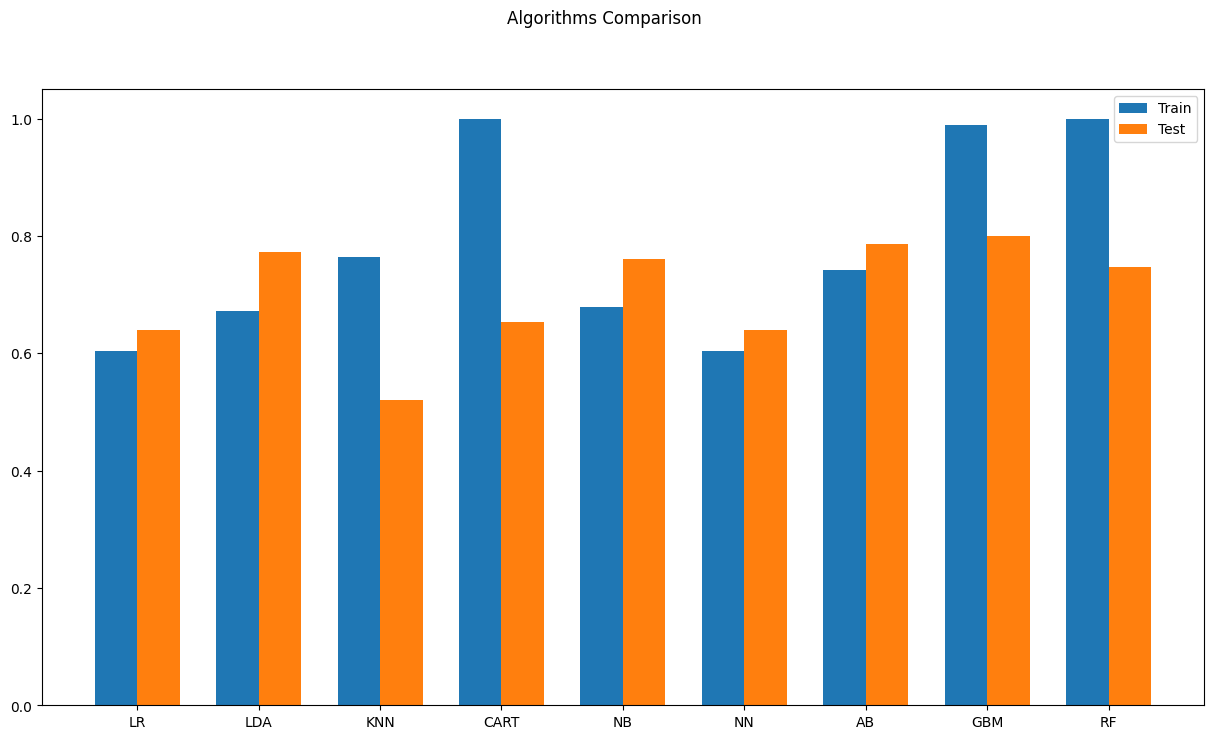

In [ ]:
# Compare algorithms
fig = pyplot.figure()
ind = np.arange(len(names))
width = 0.35
fig.suptitle('Algorithms Comparison')
ax = fig.add_subplot(111)
pyplot.bar(ind - width / 2, train_results,  width = width, label = 'Train')
pyplot.bar(ind + width / 2, test_results, width = width, label = 'Test')
fig.set_size_inches(15, 8)
pyplot.legend()
ax.set_xticks(ind)
ax.set_xticklabels(names)
pyplot.show()

Text(0.5, 0, 'Indicator Importance')

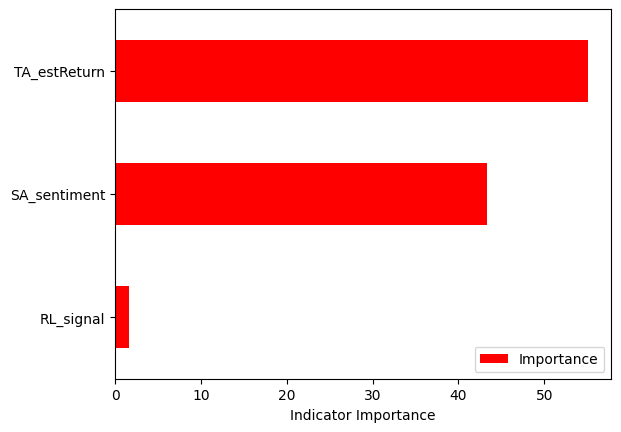

In [ ]:
Importance = pd.DataFrame({'Importance': model.feature_importances_ * 100}, index = X.columns)
Importance.sort_values('Importance', axis = 0, ascending = True).plot(kind = 'barh', color = 'r' )
plt.xlabel('Indicator Importance')

In [ ]:
# After choosing the Gradient Boosting Classifier model as the combined model, use backtrader package to simulate the trading process with testing data
model = models[7][1]
dataset_test = dataset[train_size:len(dataset)]
dataset_test['CombinedModel_Signal'] = model.predict(X_test)

In [ ]:
# setting up the backtrader simulation
class Indicate(bt.Indicator):
  lines = ('indicate',)
  plotinfo = dict(plotymargin = 0.5, plothlines = [0], plotyticks = [1.0, 0, -1.0])

  def next(self):
    self.indicate = 0.0
    self.date = self.data.datetime
    date = bt.num2date(self.date[0]).date()
    if date in date_indicate:
      self.indicate = date_indicate[date]
    self.lines.indicate[0] = self.indicate


class IndicateStrategy(bt.Strategy):
  params = (('period', 15), ('printlog', True),)

  def log(self, txt, dt=None, doprint=False):
    if self.params.printlog or doprint:
      dt = dt or self.datas[0].datetime.date(0)
      if showTradingDetails:
        print('%s, %s' % (dt.isoformat(), txt))

  def __init__(self):
    self.dataclose = self.datas[0].close
    self.order = None
    self.buyprice = None
    self.buycomm = None
    self.date = self.data.datetime
    self.indicate = None
    Indicate(self.data)
    self.plotinfo.plot = False

  def notify_order(self, order):
    if order.status in [order.Submitted, order.Accepted]:
      return
    if order.status in [order.Completed]:
      if order.isbuy(): # Buy
        if showTradingDetails:
          self.log('Buy @ %.2f' % (order.executed.price))
        self.buyprice = order.executed.price
        self.buycomm = order.executed.comm
      else:  # Sell
        if showTradingDetails:
          self.log('Sell @ %.2f' % (order.executed.price))
      self.bar_executed = len(self)
    elif order.status in [order.Canceled, order.Margin, order.Rejected]:
      if showTradingDetails:
        self.log('Order Canceled/Margin/Rejected')
    self.order = None

  def notify_trade(self, trade):
    if not trade.isclosed:
      return
    if showTradingDetails:
      self.log('^ Profit %.2f' % (trade.pnl))

  # Strategy
  def next(self):
    date = bt.num2date(self.date[0]).date()
    if date in date_indicate:
      self.indicate = date_indicate[date]
    # Check if any pending order
    if self.order:
      return
    # Check if Buy already
    if not self.position: # not in buy position
      if self.indicate >= buyTrigger:
        self.order = self.buy()
    elif self.position: # in buy position
      if self.indicate < buyTrigger:
        self.order = self.sell()

def run_strategy(ticker, start, end):
  ticker = yf.Ticker(ticker)
  df_ticker = ticker.history(start = start, end = end)
  cerebro = bt.Cerebro(cheat_on_open=True) # buy at open
  cerebro.addstrategy(IndicateStrategy)
  data = bt.feeds.PandasData(dataname = df_ticker)
  cerebro.adddata(data)
  startMoney = 100
  cerebro.broker.setcash(startMoney)
  cerebro.addsizer(bt.sizers.PercentSizer, percents = 98)
  if showTradingDetails:
    print('Starting Value: ' + str(startMoney))
  cerebro.run()
  endMoney = cerebro.broker.getvalue()
  if showTradingDetails:
    print('Ending Portfolio Value: %.2f\nProfit: %.2f\n' % (endMoney, (endMoney - startMoney)))
  return (endMoney - startMoney)

In [ ]:
# chosing the indicator and get data ready for simulation
date_indicate = dataset_test
date_indicate = date_indicate.reset_index()
date_indicate = date_indicate[['Date','CombinedModel_Signal']]
date_indicate = date_indicate.sort_values(by = 'Date', ascending = True)
date_indicate = date_indicate.set_index('Date')['CombinedModel_Signal']
date_indicate = date_indicate.to_dict()

In [ ]:
# in the simulation, if the indicator is 1 then buy (hold if already in position), otherwise sell (hold if not in position)
showTradingDetails = True
buyTrigger = 0.5
profit = run_strategy(target_tickers[0], start = dataset_test.reset_index()['Date'].min(), end = dataset_test.reset_index()['Date'].max())

Starting Value: 100
2024-08-15, Buy @ 5501.13
2024-08-23, Sell @ 5602.49
2024-08-23, ^ Profit 1.82
2024-08-26, Buy @ 5639.66
2024-08-29, Sell @ 5607.30
2024-08-29, ^ Profit -0.57
2024-08-30, Buy @ 5612.74
2024-09-04, Sell @ 5506.68
2024-09-04, ^ Profit -1.88
2024-09-05, Buy @ 5520.08
2024-09-06, Sell @ 5507.33
2024-09-06, ^ Profit -0.22
2024-09-09, Buy @ 5442.07
2024-09-19, Sell @ 5702.63
2024-09-19, ^ Profit 4.68
2024-09-20, Buy @ 5709.64
2024-09-27, Sell @ 5755.36
2024-09-27, ^ Profit 0.81
2024-09-30, Buy @ 5726.52
2024-10-02, Sell @ 5698.14
2024-10-02, ^ Profit -0.51
2024-10-03, Buy @ 5698.19
2024-10-08, Sell @ 5719.14
2024-10-08, ^ Profit 0.37
2024-10-09, Buy @ 5751.80
2024-10-11, Sell @ 5775.09
2024-10-11, ^ Profit 0.41
2024-10-14, Buy @ 5829.81
2024-10-16, Sell @ 5816.58
2024-10-16, ^ Profit -0.23
2024-10-17, Buy @ 5875.62
2024-10-18, Sell @ 5859.43
2024-10-18, ^ Profit -0.28
2024-10-22, Buy @ 5832.70
2024-10-24, Sell @ 5817.80
2024-10-24, ^ Profit -0.26
2024-10-25, Buy @ 5826.75

In [ ]:
# After showing the model is valid, save it for later use
joblib.dump(model, 'Combined_model.sav')

['Combined_model.sav']

In [ ]:
# below shows how to load the model
model_loaded = joblib.load('Combined_model.sav')